# Sign Reversal — Thesis Artifact Regeneration

Runs `scripts/regenerate_sign_reversal_thesis_artifacts.py` and renders all regenerated figures + tables inline.

**Source of truth:** `artifacts/sign_reversal_forensic_audit/sign_reversal_final_verdict.csv`

**Feature family:** `safe_core_plus_temporal` (21 features, `max_packets=300`, `min_packets=3`).


In [1]:
%matplotlib inline
import json, sys, subprocess
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
while not (ROOT / 'scripts' / 'regenerate_sign_reversal_thesis_artifacts.py').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
print('repo root:', ROOT)
AUDIT = ROOT / 'artifacts' / 'sign_reversal_forensic_audit'
FIG = AUDIT / 'figures'
TAB = AUDIT / 'tables'


repo root: C:\Users\scoti\PycharmProjects\ai-vpn-firewall


## 1. Run regeneration script

In [2]:
res = subprocess.run(
    [sys.executable, '-u', str(ROOT / 'scripts' / 'regenerate_sign_reversal_thesis_artifacts.py')],
    cwd=str(ROOT), capture_output=True, text=True,
)
print('returncode:', res.returncode)
print(res.stdout)
if res.returncode != 0:
    print('STDERR:', res.stderr)
manifest = json.loads((AUDIT / 'regenerated_artifacts_manifest.json').read_text(encoding='utf-8'))
display(Markdown(f"**Timestamp:** `{manifest['timestamp_utc']}`  \n**Git commit:** `{manifest.get('git_commit')}`"))
display(Markdown('**Category counts** (from `sign_reversal_final_verdict.csv`):'))
display(pd.DataFrame([manifest['category_counts']]).T.rename(columns={0: 'count'}))


returncode: 0
category counts: {'VERIFIED REVERSAL': 10, 'POSSIBLE ARTIFACT': 10, 'LIKELY REVERSAL BUT SENSITIVE': 1, 'NO REAL REVERSAL': 0, 'INCONCLUSIVE': 0}
{
  "status": "ok",
  "manifest": "artifacts\\sign_reversal_forensic_audit\\regenerated_artifacts_manifest.json",
  "generated": [
    "figures/sign_reversal_heatmap.png",
    "figures/reversal_sensitivity_analysis.png",
    "figures/protocol_reversal_counts.png",
    "figures/dataset_pair_reversal_contributions.png",
    "figures/top_feature_reversal_burden.png",
    "tables/sign_reversal_summary.csv",
    "tables/sign_reversal_feature_verdicts.csv",
    "tables/reversal_preprocessing_comparison.csv",
    "tables/reversal_vs_domain_fingerprint.csv",
    "tables/sign_reversal_feature_verdicts.tex"
  ],
  "warnings": []
}



**Timestamp:** `2026-04-24T00:48:53+00:00`  
**Git commit:** `e1f72e8fbd718be9f2be7cd96403fc75990bf378`

**Category counts** (from `sign_reversal_final_verdict.csv`):

,count
VERIFIED REVERSAL,10
LIKELY REVERSAL BUT SENSITIVE,1
POSSIBLE ARTIFACT,10
NO REAL REVERSAL,0
INCONCLUSIVE,0


## 2. Consistency checks

In [3]:
display(pd.Series(manifest['consistency_checks']).to_frame('value'))
if manifest['warnings']:
    display(Markdown(f"⚠️ Warnings: {manifest['warnings']}"))
else:
    display(Markdown('✅ No warnings.'))


,value
label_mapping_ok_all_datasets,False
raw_recomputation_exact_match_rate_min,1.0
direction_safe_all_21,True
computed_identically_across_datasets,True
preprocessing_source_identified,True


✅ No warnings.

## 3. Figure 1 — Sign-reversal heatmap (raw-space, per dataset)

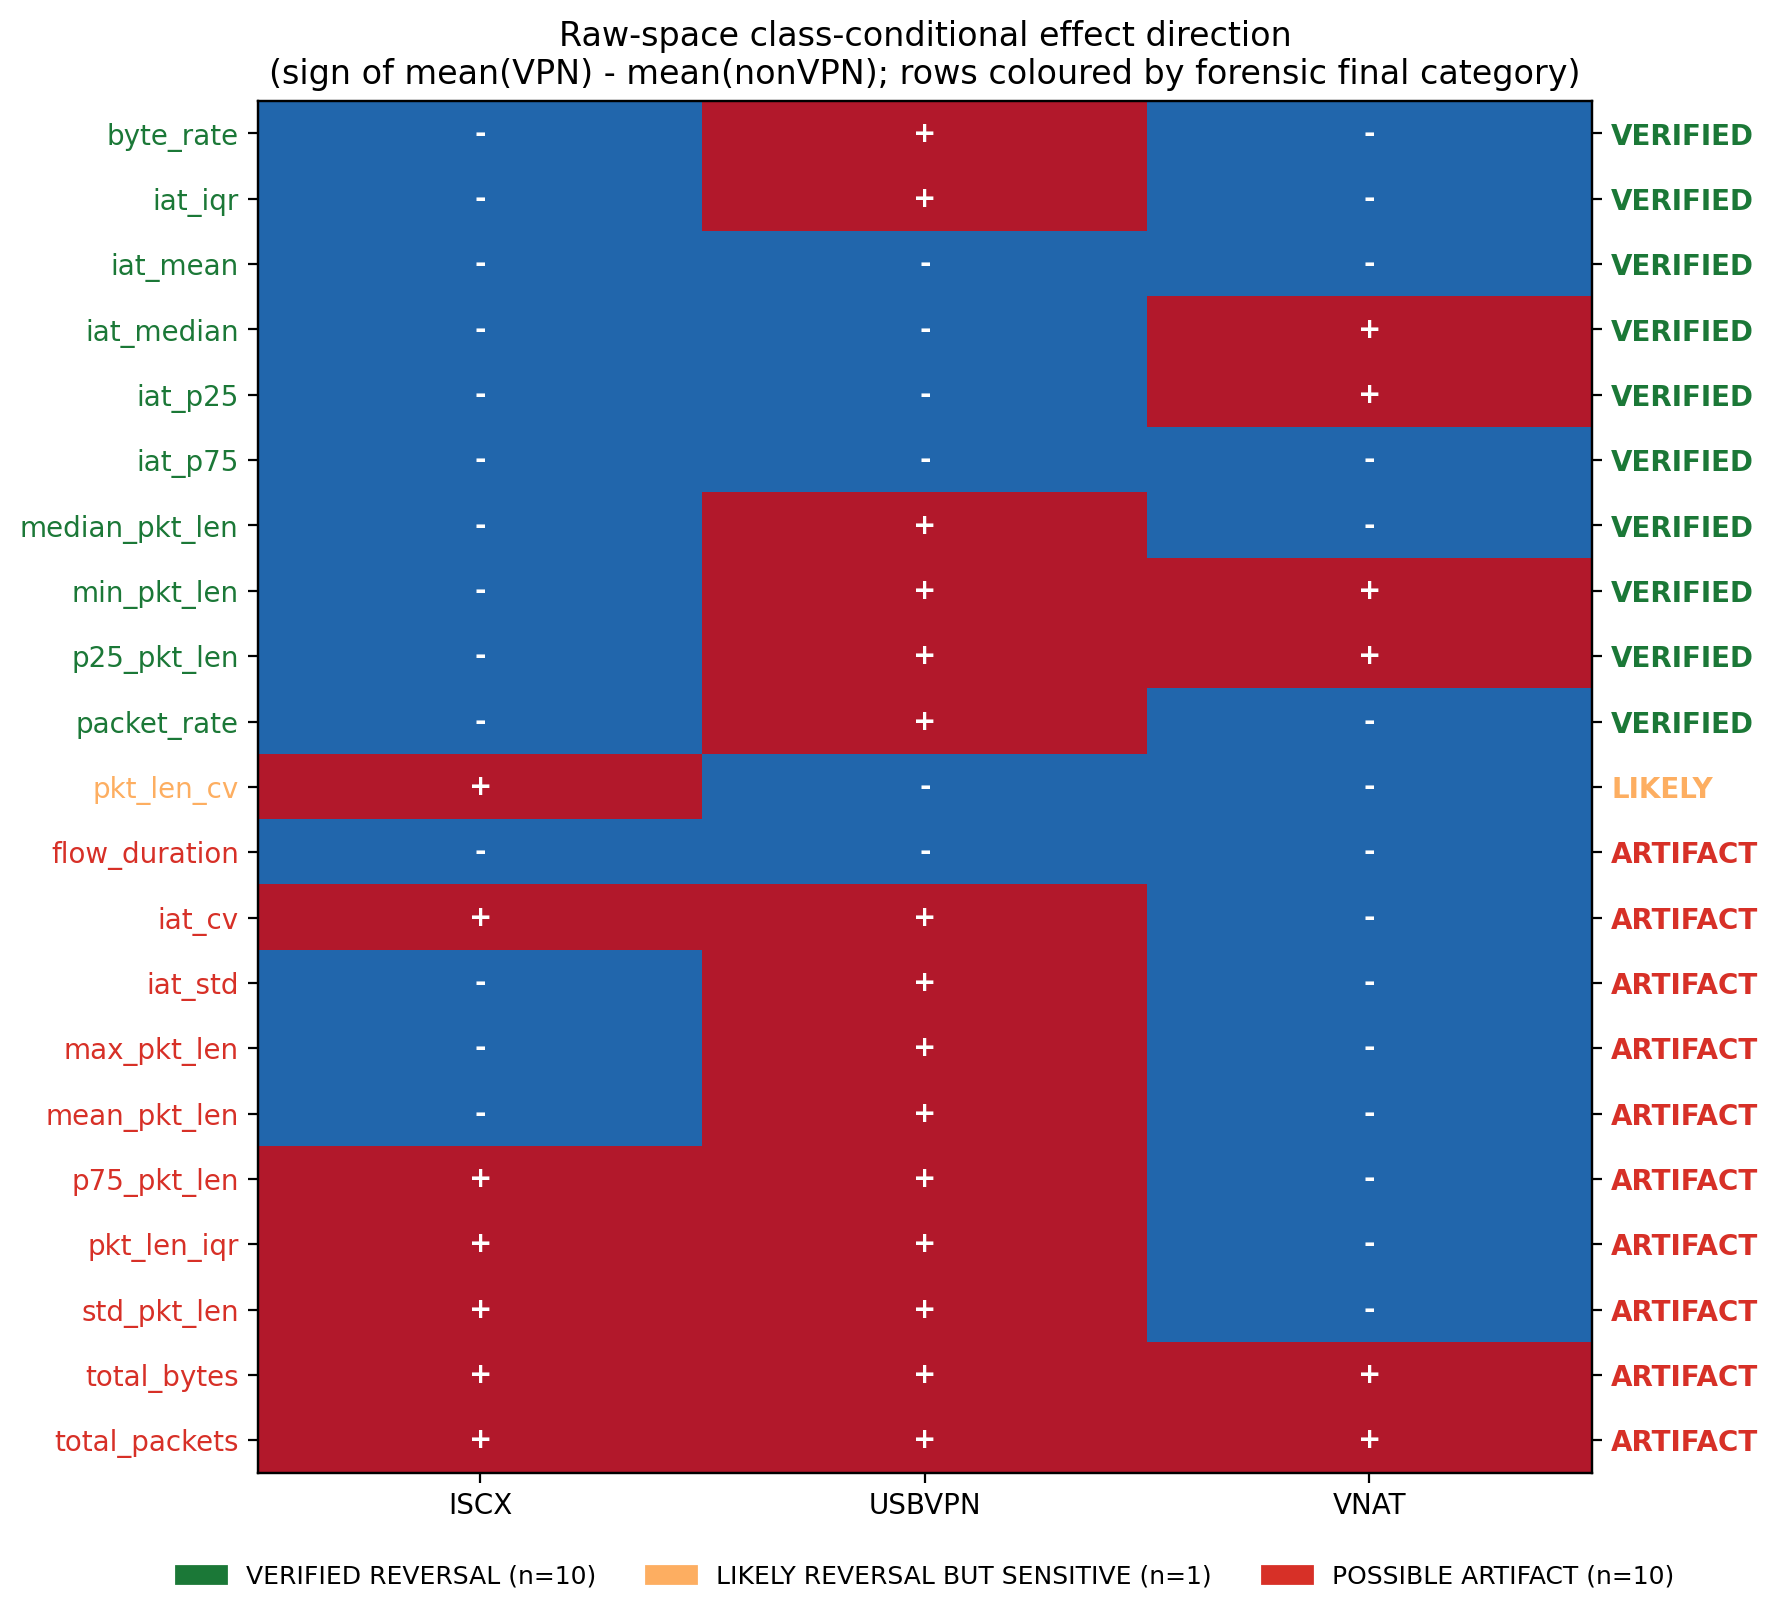

In [4]:
display(Image(filename=str(FIG / 'sign_reversal_heatmap.png')))


## 4. Figure 2 — Reversal sensitivity to preprocessing

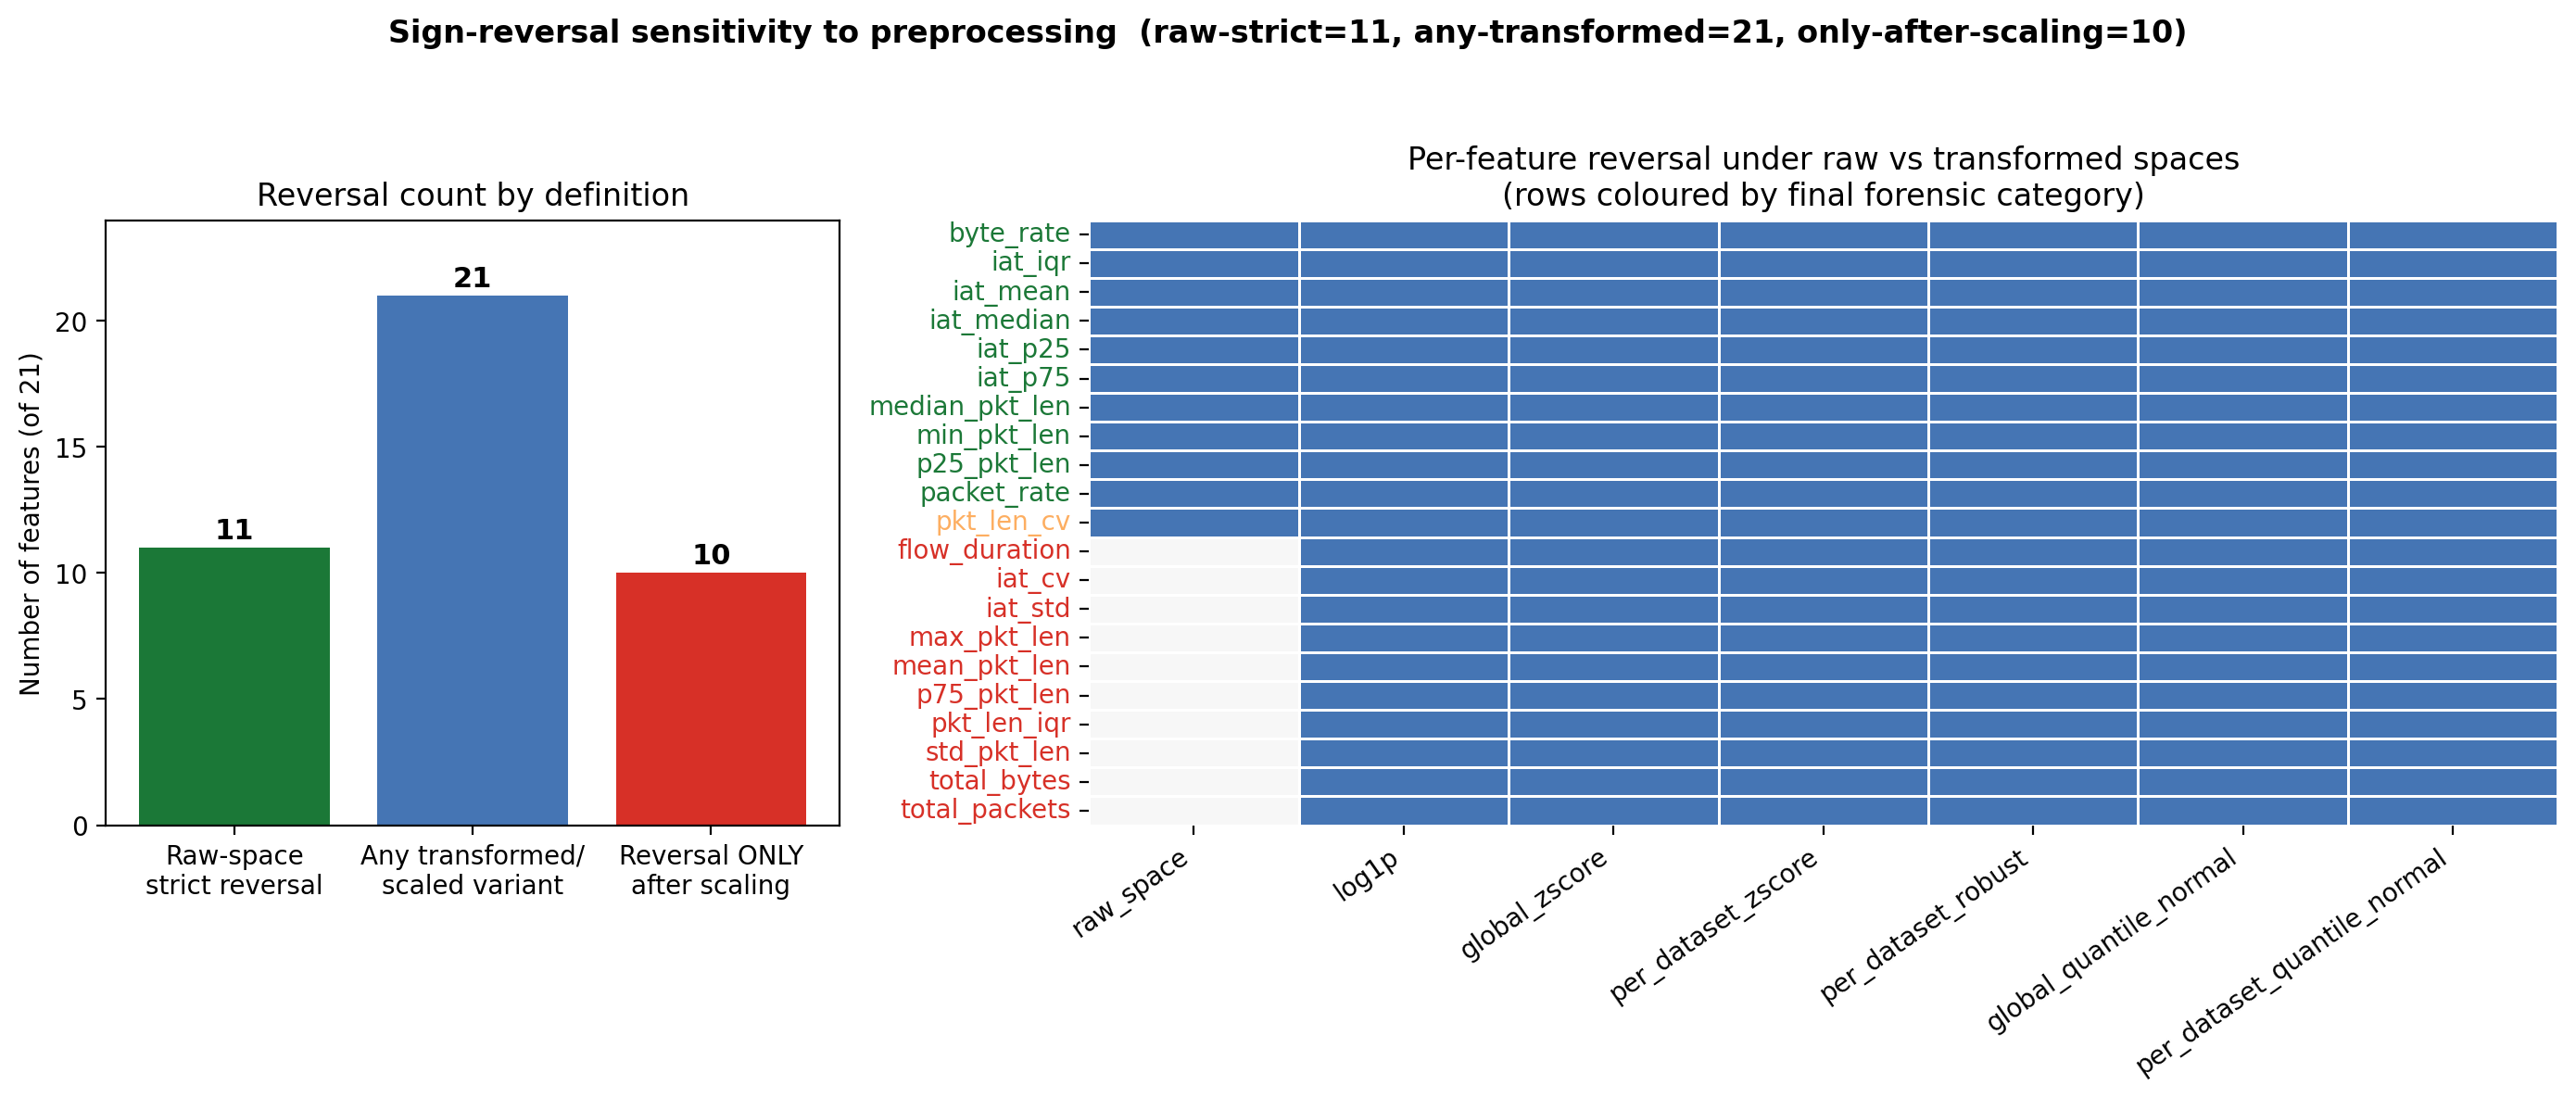

In [5]:
display(Image(filename=str(FIG / 'reversal_sensitivity_analysis.png')))


## 5. Figure 3 — Final-category reversal counts (supersedes old 16/21 figure)

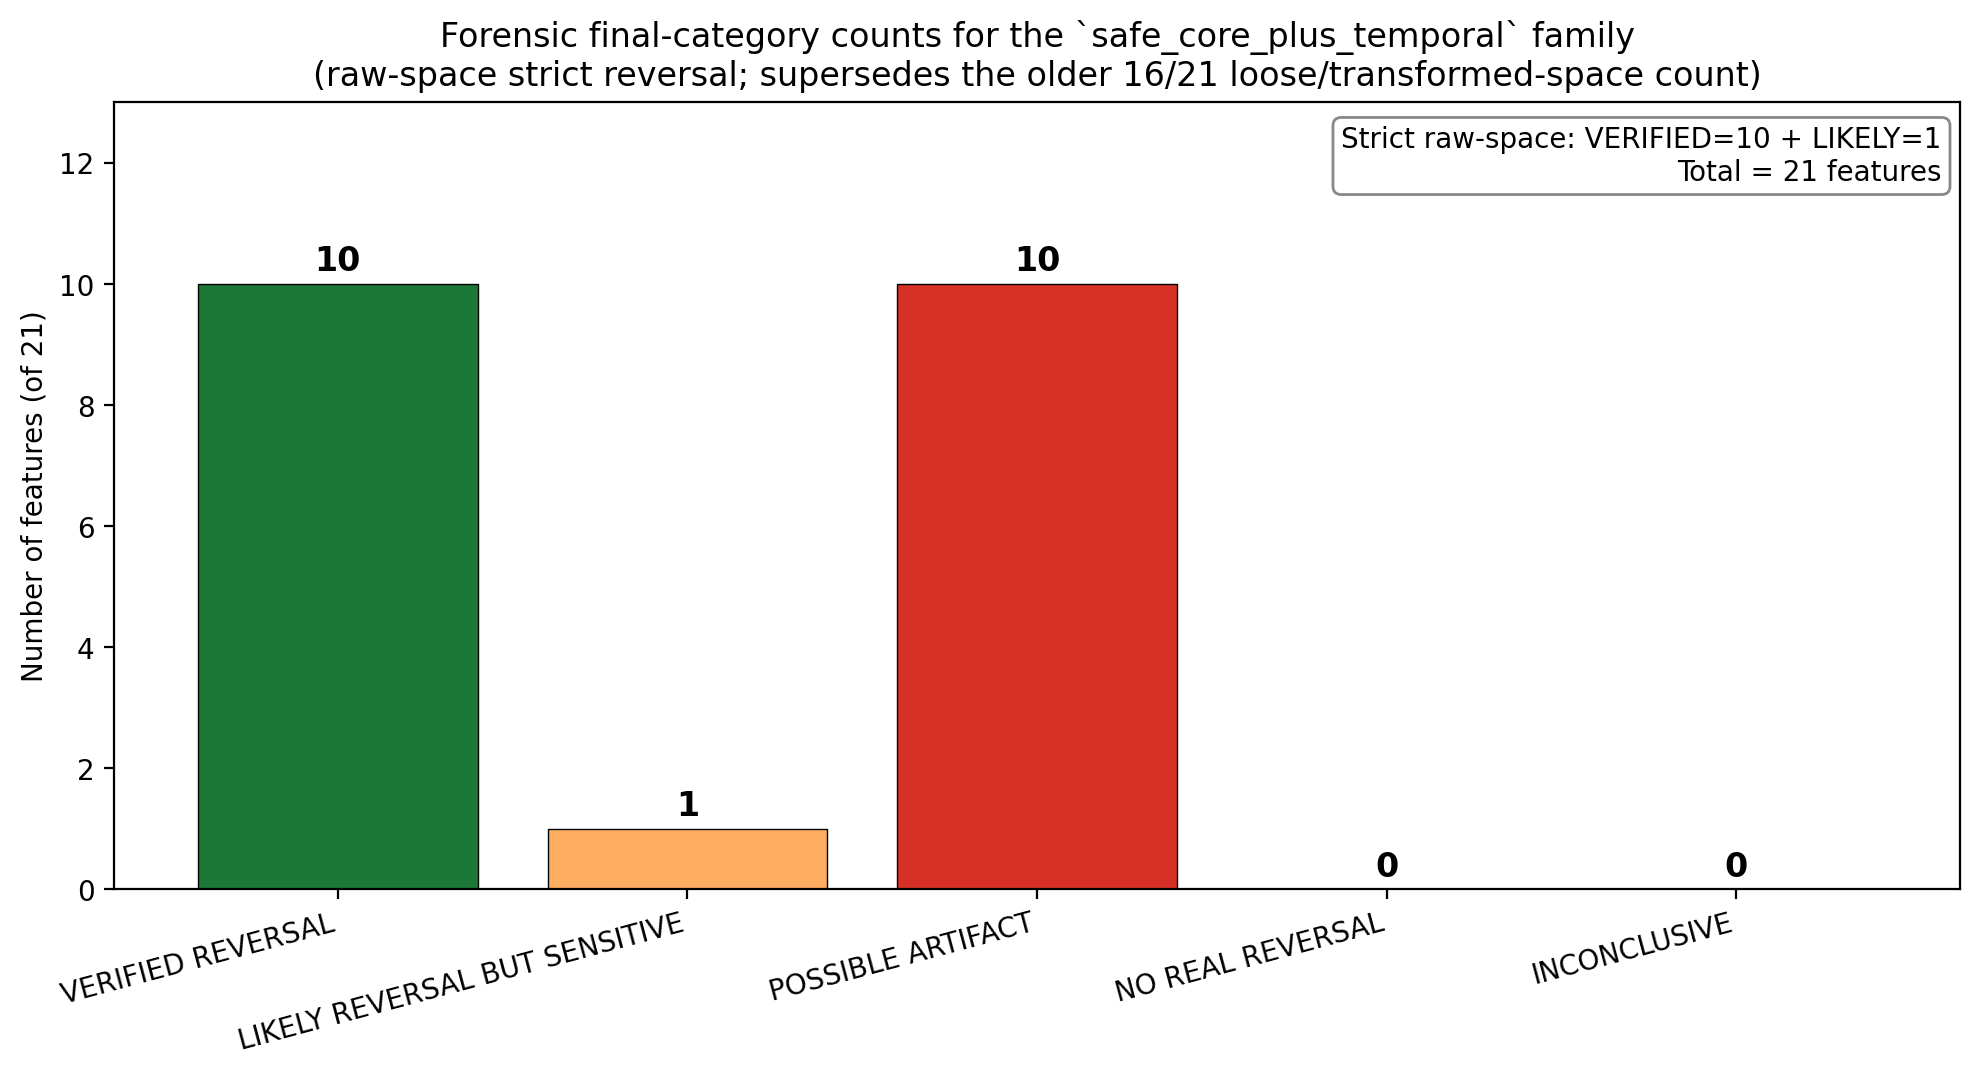

In [6]:
display(Image(filename=str(FIG / 'protocol_reversal_counts.png')))


## 6. Figure 4 — Dataset-pair reversal contributions (strict vs loose, separate panels)

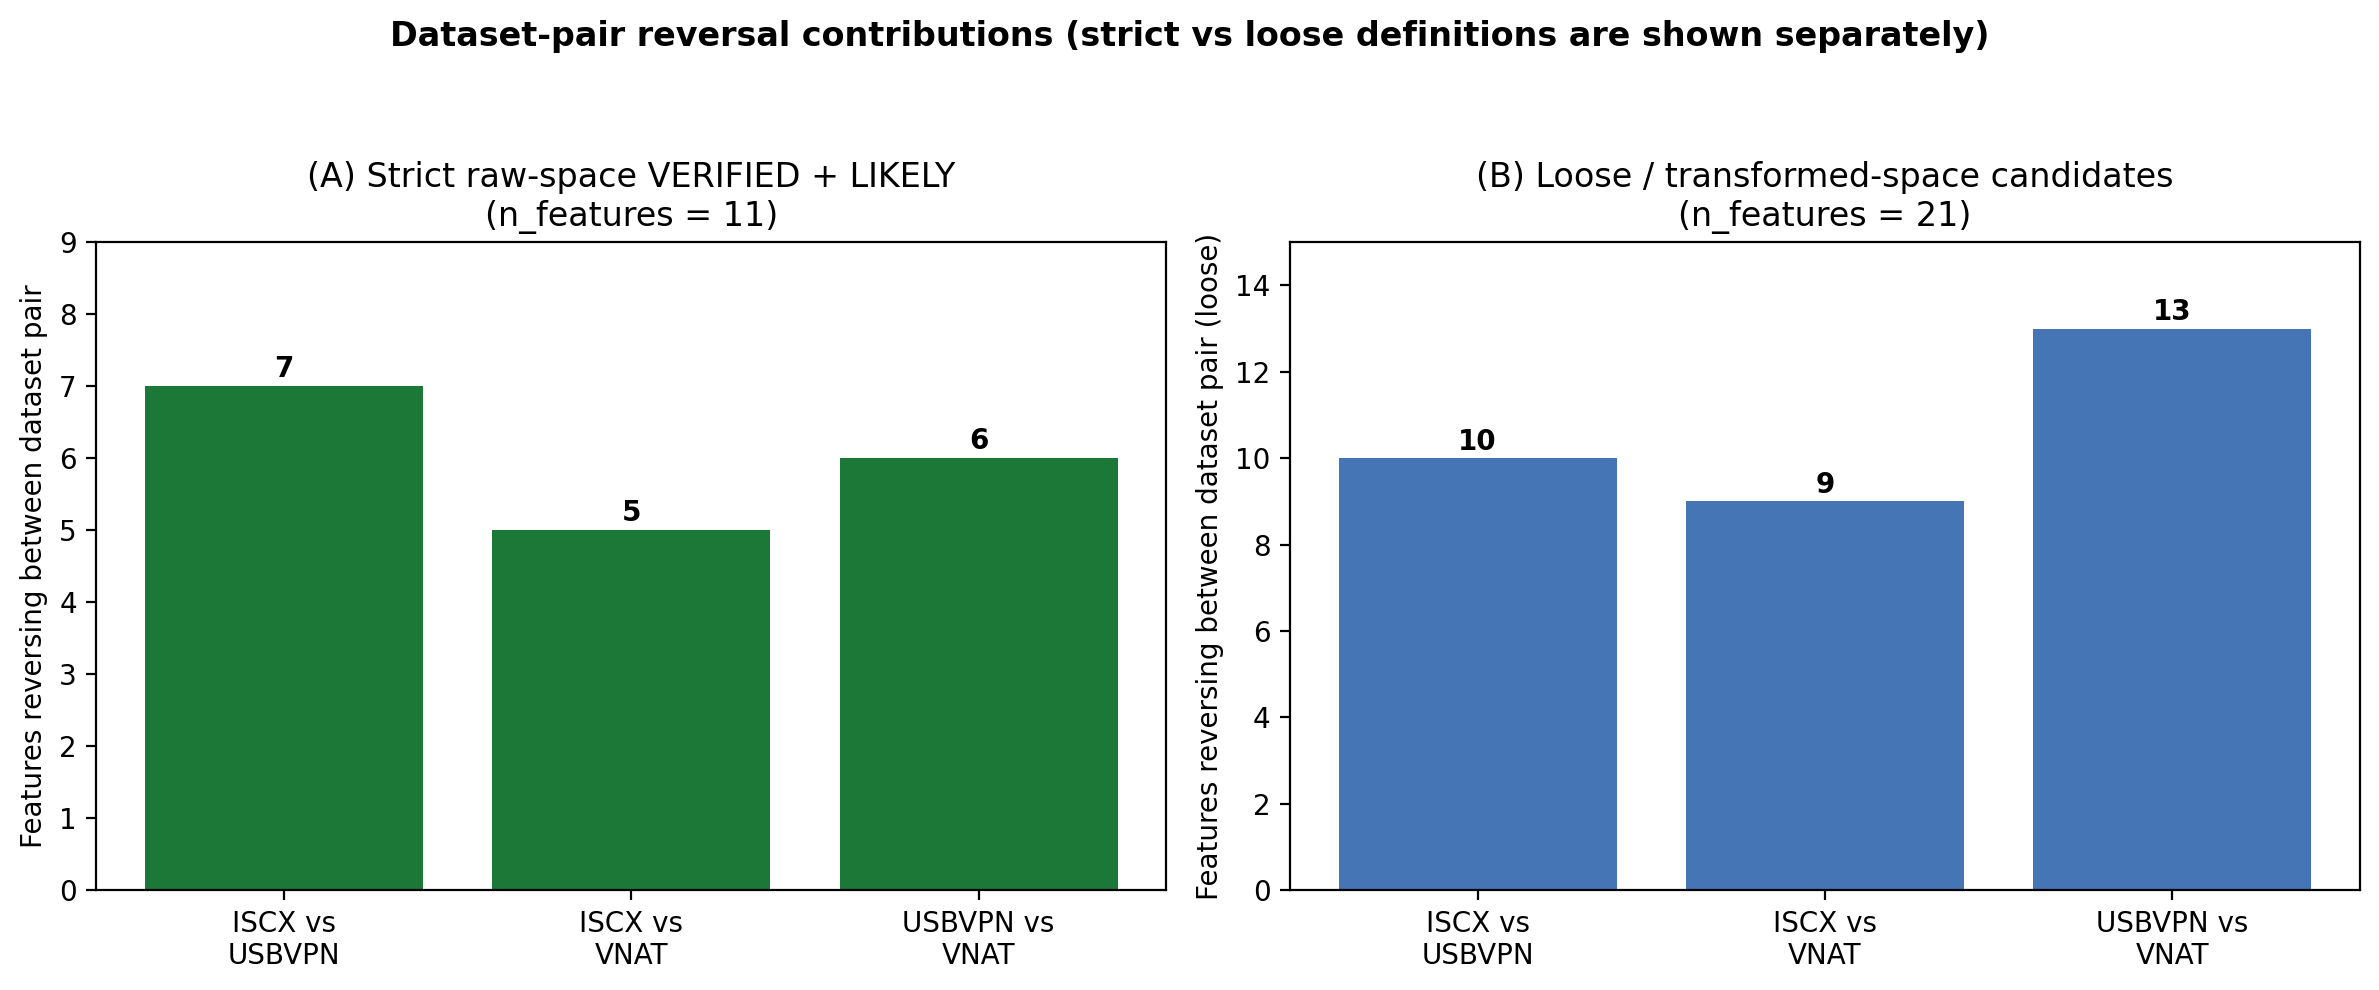

In [7]:
display(Image(filename=str(FIG / 'dataset_pair_reversal_contributions.png')))


## 7. Figure 5 — Top-feature reversal burden (three definitions)

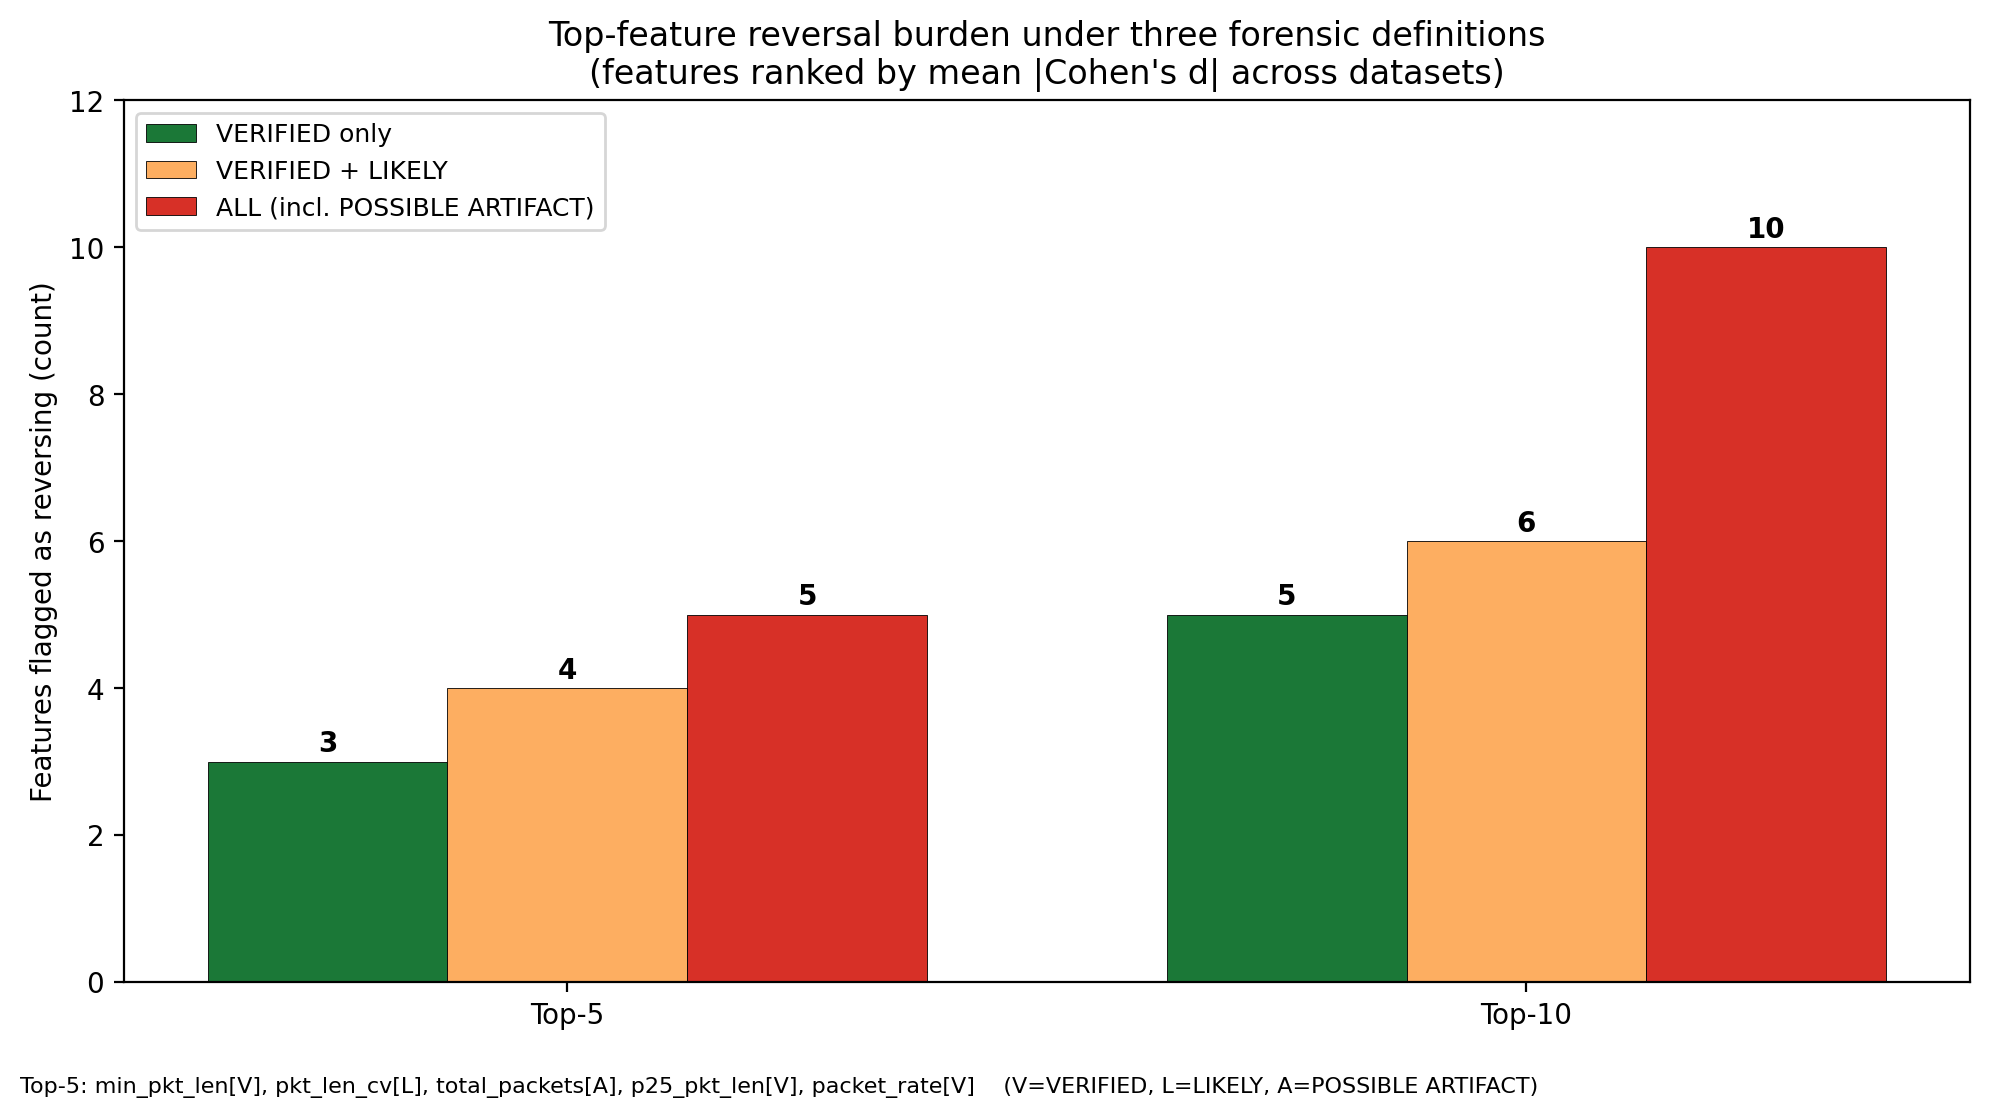

,scope,VERIFIED only,VERIFIED + LIKELY,ALL (incl. POSSIBLE ARTIFACT)
0,Top-5,3,4,5
1,Top-10,5,6,10


**Top-5 / Top-10 features with tag (V=VERIFIED, L=LIKELY, A=POSSIBLE ARTIFACT):**

{'top5': ['min_pkt_len',
  'pkt_len_cv',
  'total_packets',
  'p25_pkt_len',
  'packet_rate'],
 'top10': ['min_pkt_len',
  'pkt_len_cv',
  'total_packets',
  'p25_pkt_len',
  'packet_rate',
  'byte_rate',
  'median_pkt_len',
  'total_bytes',
  'mean_pkt_len',
  'iat_cv'],
 'top5_categories': {'min_pkt_len': 'V',
  'pkt_len_cv': 'L',
  'total_packets': 'A',
  'p25_pkt_len': 'V',
  'packet_rate': 'V'},
 'top10_categories': {'min_pkt_len': 'V',
  'pkt_len_cv': 'L',
  'total_packets': 'A',
  'p25_pkt_len': 'V',
  'packet_rate': 'V',
  'byte_rate': 'V',
  'median_pkt_len': 'V',
  'total_bytes': 'A',
  'mean_pkt_len': 'A',
  'iat_cv': 'A'}}

In [8]:
display(Image(filename=str(FIG / 'top_feature_reversal_burden.png')))
display(pd.read_csv(TAB / 'top_feature_reversal_burden.csv'))
display(Markdown('**Top-5 / Top-10 features with tag (V=VERIFIED, L=LIKELY, A=POSSIBLE ARTIFACT):**'))
display(json.loads((TAB / 'top_feature_reversal_burden_features.json').read_text(encoding='utf-8')))


## 8. Thesis-ready per-feature verdict table

In [9]:
verdicts = pd.read_csv(TAB / 'sign_reversal_feature_verdicts.csv')
def _style(row):
    color = {
        'VERIFIED REVERSAL': 'background-color: #d0ecd0',
        'LIKELY REVERSAL BUT SENSITIVE': 'background-color: #fde7c7',
        'POSSIBLE ARTIFACT': 'background-color: #f4c7c3',
    }.get(row['final_category'], '')
    return [color] * len(row)
verdicts.style.apply(_style, axis=1)


,feature,strict_reversal_metric_count,loose_reversal_metric_count,reversal_raw_space,reversal_introduced_only_after_scaling,reversal_stable_across_preprocessing_variants,robustness_tag,final_category,thesis_level_claim_verdict
0,p25_pkt_len,8,8,True,False,True,robust,VERIFIED REVERSAL,B. partially supported
1,byte_rate,7,8,True,False,True,robust,VERIFIED REVERSAL,B. partially supported
2,min_pkt_len,7,7,True,False,True,robust,VERIFIED REVERSAL,B. partially supported
3,packet_rate,7,8,True,False,True,robust,VERIFIED REVERSAL,B. partially supported
4,iat_iqr,4,4,True,False,True,robust,VERIFIED REVERSAL,B. partially supported
5,iat_mean,4,4,True,False,True,robust,VERIFIED REVERSAL,B. partially supported
6,iat_median,4,4,True,False,True,robust,VERIFIED REVERSAL,B. partially supported
7,iat_p75,4,4,True,False,True,robust,VERIFIED REVERSAL,B. partially supported
8,iat_p25,3,4,True,False,True,robust,VERIFIED REVERSAL,B. partially supported
9,median_pkt_len,3,3,True,False,True,robust,VERIFIED REVERSAL,B. partially supported


## 9. Aggregate summary

In [10]:
display(pd.read_csv(TAB / 'sign_reversal_summary.csv').T.rename(columns={0: 'value'}))


,value
feature_family,safe_core_plus_temporal
n_total_features,21
n_verified_reversal,10
n_likely_reversal_but_sensitive,1
n_possible_artifact,10
n_no_real_reversal,0
n_inconclusive,0
n_strict_consensus_reversal_raw_space,11
n_reversal_only_after_scaling,10
thesis_level_claim_verdict,B. partially supported


## 10. Thesis chapter replacement sentence

In [11]:
display(Markdown(f"**Old claim to replace:** _{manifest['old_claim_to_replace']}_"))
display(Markdown(f"**New thesis sentence:**\n\n> {manifest['thesis_claim_text_replacement']}"))


**Old claim to replace:** _16 of 21 features show triple-consensus reversal_

**New thesis sentence:**

> 11 of 21 features show strict consensus reversal under the completed raw-space forensic audit, of which 10 are verified and 1 is/are likely but sensitive. The remaining 10 features show possible artifact behaviour, mainly because reversal appears only after transformed-space or scaled variants.

## 11. LaTeX table preview

In [12]:
print((TAB / 'sign_reversal_feature_verdicts.tex').read_text(encoding='utf-8'))


% Auto-generated by scripts/regenerate_sign_reversal_thesis_artifacts.py
% Source: artifacts/sign_reversal_forensic_audit/sign_reversal_final_verdict.csv
\begin{table}[t]
\centering
\small
\caption{Per-feature forensic verdict for the \texttt{safe\_core\_plus\_temporal} family. Strict / loose metric counts are out of 8 independent direction metrics; a feature is in \textbf{VERIFIED} only if it reverses in raw space and survives bootstrap + capture + preprocessing checks.}
\label{tab:sign-reversal-verdicts}
\begin{tabular}{lrrcccll}
\toprule
Feature & Strict & Loose & Raw-space & Only after scaling & Stable prep. & Robustness & Final category \\
\midrule
p25\_pkt\_len & 8 & 8 & \checkmark & -- & \checkmark & robust & \textbf{VERIFIED} \\
byte\_rate & 7 & 8 & \checkmark & -- & \checkmark & robust & \textbf{VERIFIED} \\
min\_pkt\_len & 7 & 7 & \checkmark & -- & \checkmark & robust & \textbf{VERIFIED} \\
packet\_rate & 7 & 8 & \checkmark & -- & \checkmark & robust & \textbf{VERIFIED} \\
ia

## 12. Manifest — generated artifacts

In [13]:
display(pd.Series(manifest['generated_artifacts']).to_frame('relative_path'))


,relative_path
figures/sign_reversal_heatmap.png,artifacts\sign_reversal_forensic_audit\figures...
figures/reversal_sensitivity_analysis.png,artifacts\sign_reversal_forensic_audit\figures...
figures/protocol_reversal_counts.png,artifacts\sign_reversal_forensic_audit\figures...
figures/dataset_pair_reversal_contributions.png,artifacts\sign_reversal_forensic_audit\figures...
figures/top_feature_reversal_burden.png,artifacts\sign_reversal_forensic_audit\figures...
tables/sign_reversal_summary.csv,artifacts\sign_reversal_forensic_audit\tables\...
tables/sign_reversal_feature_verdicts.csv,artifacts\sign_reversal_forensic_audit\tables\...
tables/reversal_preprocessing_comparison.csv,artifacts\sign_reversal_forensic_audit\tables\...
tables/reversal_vs_domain_fingerprint.csv,artifacts\sign_reversal_forensic_audit\tables\...
tables/sign_reversal_feature_verdicts.tex,artifacts\sign_reversal_forensic_audit\tables\...
